# 01 — Exploratory Data Analysis

**Amazon Reviews 2023 — Home & Kitchen Subset**

Dataset: 99,946 reviews × 83,119 products. No product metadata — titles derived from most-helpful review headline.

Run `make etl && make index` before executing this notebook.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import duckdb
from pathlib import Path

%matplotlib inline
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

DB = Path('../data/amazon_reviews.duckdb')
conn = duckdb.connect(str(DB), read_only=True)
print('Connected.')

Connected.


## 1. Load Tables

In [2]:
reviews = conn.execute('SELECT * FROM reviews').df()
products = conn.execute('SELECT * FROM products').df()

print(f'Reviews:  {len(reviews):>7,}  rows × {len(reviews.columns)} cols')
print(f'Products: {len(products):>7,}  rows × {len(products.columns)} cols')
reviews.dtypes

Reviews:   99,946  rows × 13 cols
Products:  83,119  rows × 15 cols


review_id                       str
asin                            str
user_id                         str
rating                      float32
title                           str
text                            str
helpful_vote                  int32
verified_purchase              bool
sentiment_label                 str
review_length                 int32
word_count                    int32
timestamp                     int64
review_datetime      datetime64[us]
dtype: object

In [3]:
reviews.head(3)

,review_id,asin,user_id,rating,title,text,helpful_vote,verified_purchase,sentiment_label,review_length,word_count,timestamp,review_datetime
0,3586754028921586910,B00LS9UD2M,AGSXRYUCT4QQZ6NLIU5PTKAMVSQA,4.0,great quality.,"Heavy, great quality.",0,True,positive,21,3,1451769013000,2016-01-02 21:10:13
1,3387145141138700089,B07PDHKLLQ,AFXMJCVLRCGRAEC7P37FZHEB24UQ,5.0,Perfect Bags,I love these bags. Great colors and well made....,0,False,positive,236,44,1559595880218,2019-06-03 21:04:40
2,17446360092547265585,B08TTG4CSM,AGD25H7BIT2JUXSIOPYCYB23J3ZQ,5.0,Very happy with this!,"Pretty!!! Bigger than I expected, which is awe...",0,False,positive,279,50,1624203253471,2021-06-20 15:34:13


## 2. Dataset Overview

In [4]:
reviews['dt'] = pd.to_datetime(reviews['timestamp'] / 1000, unit='s', errors='coerce')

stats = {
    'Total reviews':               f"{len(reviews):,}",
    'Unique products (reviews)':   f"{reviews['asin'].nunique():,}",
    'Unique reviewers':            f"{reviews['user_id'].nunique():,}",
    'Products table':              f"{len(products):,}",
    'Mean rating':                 f"{reviews['rating'].mean():.3f}",
    'Median rating':               f"{reviews['rating'].median():.1f}",
    '% verified purchase':         f"{reviews['verified_purchase'].mean()*100:.1f}%",
    '% negative (≤2★)':           f"{(reviews['rating'] <= 2).mean()*100:.1f}%",
    'Date range':                  f"{reviews['dt'].min().date()} to {reviews['dt'].max().date()}",
}
for k, v in stats.items():
    print(f'{k:<35s} {v}')

Total reviews                       99,946
Unique products (reviews)           83,119
Unique reviewers                    6,801
Products table                      83,119
Mean rating                         4.392
Median rating                       5.0
% verified purchase                 70.8%
% negative (≤2★)                    9.1%
Date range                          2000-08-06 to 2023-03-17


## 3. Rating Distributions

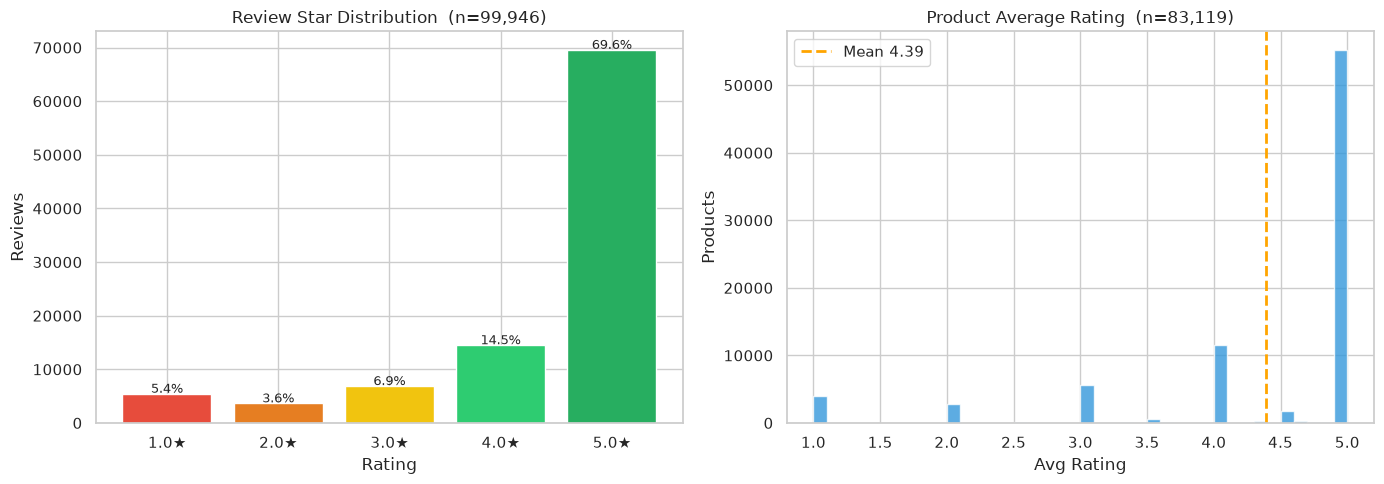

Insight: 5★ dominates (J-curve typical of Amazon reviews, most silent buyers are satisfied).


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Review-level star distribution
rc = reviews['rating'].value_counts().sort_index()
colors = ['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60']
bars = axes[0].bar([f'{r}★' for r in rc.index], rc.values, color=colors)
axes[0].set_title('Review Star Distribution  (n=99,946)')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Reviews')
for bar, val in zip(bars, rc.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val/len(reviews)*100:.1f}%', ha='center', fontsize=9)

# Product-level avg_rating distribution
axes[1].hist(products['avg_rating'].dropna(), bins=40, color='#3498db', alpha=0.8)
mean_r = products['avg_rating'].mean()
axes[1].axvline(mean_r, color='orange', linestyle='--', linewidth=2, label=f'Mean {mean_r:.2f}')
axes[1].set_title('Product Average Rating  (n=83,119)')
axes[1].set_xlabel('Avg Rating')
axes[1].set_ylabel('Products')
axes[1].legend()

plt.tight_layout()
plt.savefig('../docs/screenshots/eda_ratings.png', dpi=150, bbox_inches='tight')
plt.show()

print('Insight: 5★ dominates (J-curve typical of Amazon reviews, most silent buyers are satisfied).')

## 4. Review Length vs Rating

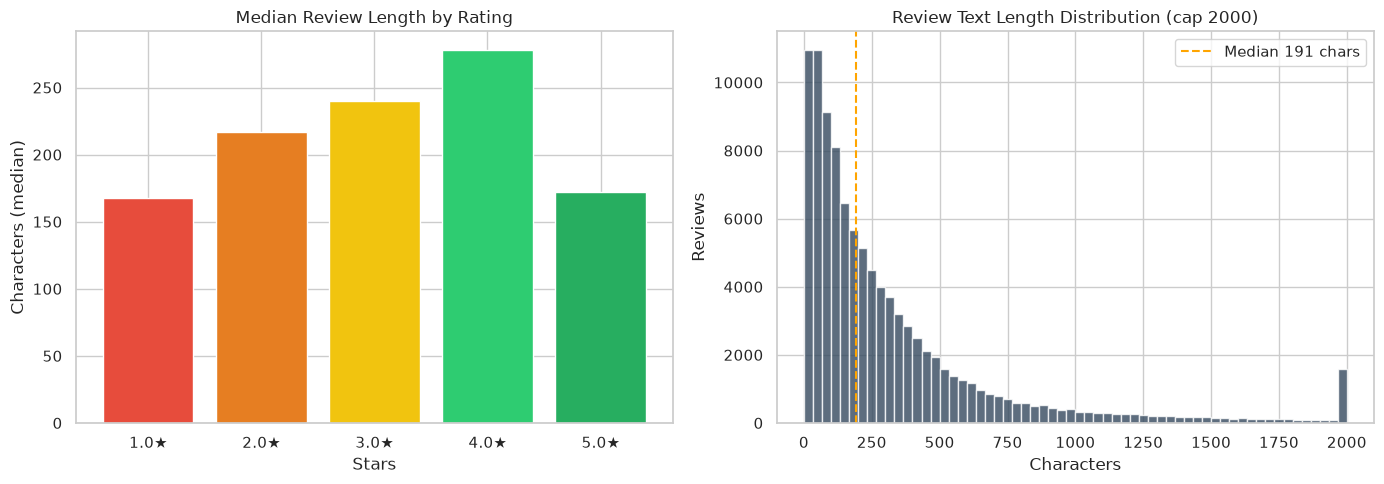

Insight: 1★ and 2★ reviews are LONGER — dissatisfied buyers explain themselves more.


In [6]:
reviews['text_len'] = reviews['text'].str.len().fillna(0).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Median review length by star
by_star = reviews.groupby('rating')['text_len'].median()
axes[0].bar([f'{r}★' for r in by_star.index], by_star.values, color=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60'])
axes[0].set_title('Median Review Length by Rating')
axes[0].set_xlabel('Stars')
axes[0].set_ylabel('Characters (median)')

# Distribution (capped)
axes[1].hist(reviews['text_len'].clip(0, 2000), bins=60, color='#34495e', alpha=0.8)
med = reviews['text_len'].median()
axes[1].axvline(med, color='orange', linestyle='--', label=f'Median {med:.0f} chars')
axes[1].set_title('Review Text Length Distribution (cap 2000)')
axes[1].set_xlabel('Characters')
axes[1].set_ylabel('Reviews')
axes[1].legend()

plt.tight_layout()
plt.savefig('../docs/screenshots/eda_review_length.png', dpi=150, bbox_inches='tight')
plt.show()

print('Insight: 1★ and 2★ reviews are LONGER — dissatisfied buyers explain themselves more.')

## 5. User & Product Sparsity (Collaborative Filtering Feasibility)

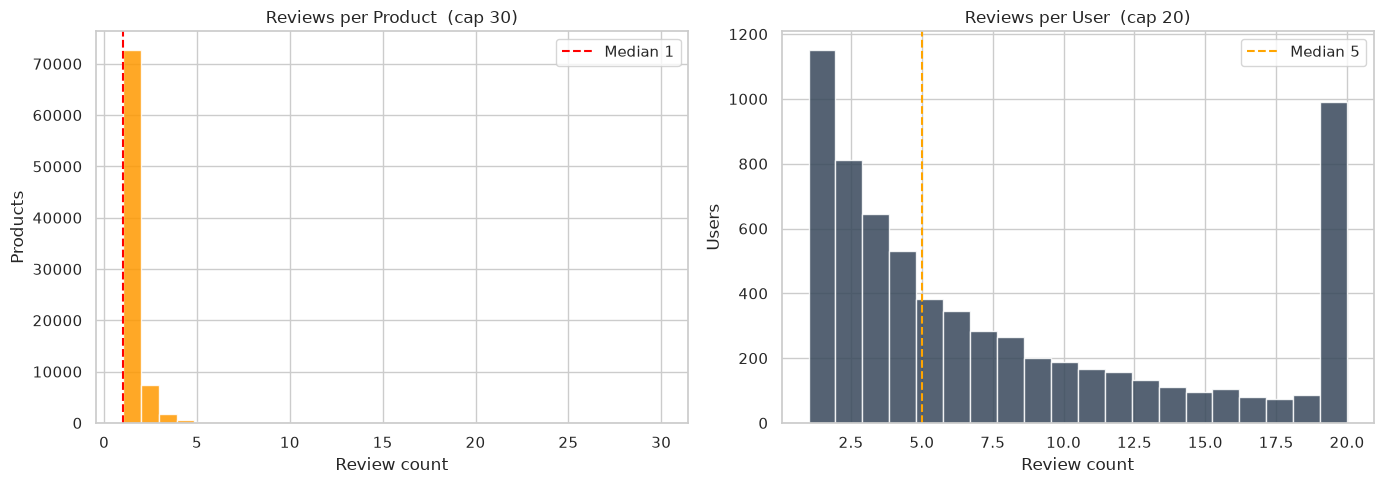

Matrix: 6,801 users × 83,119 products
Density: 0.0177%  (extreme sparsity — CF needs content or cold-start fallback)
Products with only 1 review: 72,689 (87.5%)


In [7]:
rpp = reviews.groupby('asin').size()
rpu = reviews.groupby('user_id').size()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(rpp.clip(0, 30), bins=30, color='#FF9900', alpha=0.85)
axes[0].set_title('Reviews per Product  (cap 30)')
axes[0].set_xlabel('Review count')
axes[0].set_ylabel('Products')
axes[0].axvline(rpp.median(), color='red', linestyle='--', label=f'Median {rpp.median():.0f}')
axes[0].legend()

axes[1].hist(rpu.clip(0, 20), bins=20, color='#37475A', alpha=0.85)
axes[1].set_title('Reviews per User  (cap 20)')
axes[1].set_xlabel('Review count')
axes[1].set_ylabel('Users')
axes[1].axvline(rpu.median(), color='orange', linestyle='--', label=f'Median {rpu.median():.0f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('../docs/screenshots/eda_sparsity.png', dpi=150, bbox_inches='tight')
plt.show()

total_cells = reviews['asin'].nunique() * reviews['user_id'].nunique()
density = len(reviews) / total_cells * 100
print(f'Matrix: {reviews["user_id"].nunique():,} users × {reviews["asin"].nunique():,} products')
print(f'Density: {density:.4f}%  (extreme sparsity — CF needs content or cold-start fallback)')
print(f'Products with only 1 review: {(rpp==1).sum():,} ({(rpp==1).mean()*100:.1f}%)')

## 6. Temporal Trends

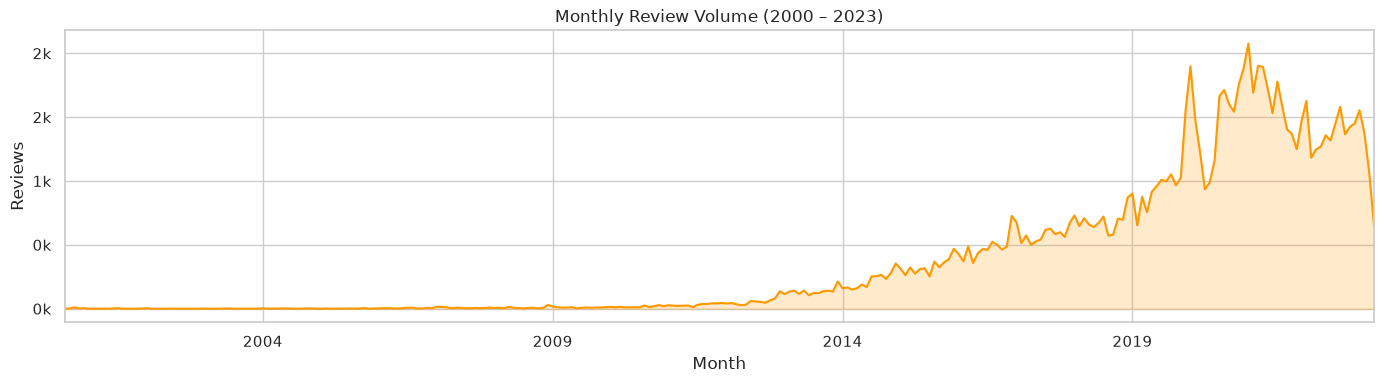

Peak month: 2021-01 (2,076 reviews)
This subset covers the single category Home & Kitchen — seasonality visible (holiday peaks).


In [8]:
monthly = reviews.set_index('dt').resample('ME')['review_id'].count()

fig, ax = plt.subplots(figsize=(14, 4))
monthly.plot(ax=ax, color='#FF9900', linewidth=1.5)
ax.fill_between(monthly.index, monthly.values, alpha=0.2, color='#FF9900')
ax.set_title('Monthly Review Volume (2000 – 2023)')
ax.set_xlabel('Month')
ax.set_ylabel('Reviews')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
plt.tight_layout()
plt.savefig('../docs/screenshots/eda_volume.png', dpi=150, bbox_inches='tight')
plt.show()

peak_month = monthly.idxmax().strftime('%Y-%m')
print(f'Peak month: {peak_month} ({monthly.max():,} reviews)')
print(f'This subset covers the single category Home & Kitchen — seasonality visible (holiday peaks).')

## 7. Sentiment Breakdown

Sentiment label distribution:
sentiment_label
positive    84031
negative     9057
neutral      6858


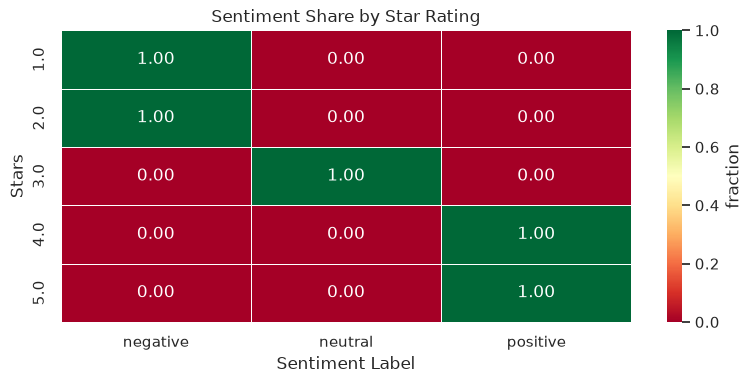


EDA complete. All plots saved to docs/screenshots/.


In [9]:
sent = reviews['sentiment_label'].value_counts()
print('Sentiment label distribution:')
print(sent.to_string())

# Sentiment vs rating heatmap
cross = pd.crosstab(reviews['rating'], reviews['sentiment_label'], normalize='index')

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(cross, annot=True, fmt='.2f', cmap='RdYlGn', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'fraction'})
ax.set_title('Sentiment Share by Star Rating')
ax.set_xlabel('Sentiment Label')
ax.set_ylabel('Stars')
plt.tight_layout()
plt.savefig('../docs/screenshots/eda_sentiment_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

conn.close()
print('\nEDA complete. All plots saved to docs/screenshots/.')